In [1]:
import pandas as pd

import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# load in the Playground Equipment data file
data = pd.read_csv("https://data.wprdc.org/datastore/dump/e39ef76e-0a11-47c8-a86f-a37f55db7a2b")

# look at the first ten rows of the data,
data.sample(10)

,_id,id,name,equipment_type,manufacturer,safety_surface_type,ada_accessible,street_number,street,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
194,195,1412828232,Eleanor St. Playground,Play Area 2 to 5,Playworld,Greenpark Breakfall,f,2314.0,Sierra St,South Side Slopes,3,16,42003160800,3,16,3,4-22,40.421528,-79.973019
8,9,1315630398,Chartiers Playground,Play Area 5 to 12,Little Tykes,SofSurfaces,f,1544.0,Summerdale St,Windgap,2,28,42003563000,5,28,6,1-16,40.456681,-80.075019
111,112,1511493492,Able Long Playground,Play Area 5 to 12,Little Tykes,Pour in Place,f,211.0,Coast Ave,Beechview,4,19,42003192000,5,19,6,4-28,40.408362,-80.028426
198,199,605577287,Mt. Washington Playground,Play Area 5 to 12,Playworld,SofSurfaces,f,726.0,Kuhn St,Mount Washington,2,19,42003191400,5,19,3,4-27,40.424612,-80.013236
322,323,1639055373,Lookout Street Playground,Spinner,Gametime,SofSurfaces,f,NaN,Lookout St,Troy Hill,1,24,42003240600,1,24,1,1-2,40.469427,-79.977083
174,175,1420904227,Bud Hammer Playground,Swing 3 Bays,Little Tykes,Pour in Place,f,122.0,Bigelow St,Hazelwood,5,15,42003562900,3,15,4,2-12,40.421510,-79.947235
280,281,1856987232,Vincennes Playground,Play Area 5 to 12,Little Tykes,Pour in Place,f,2850.0,Webster Ave,Middle Hill,6,5,42003050100,3,5,2,2-5,40.451371,-79.967465
46,47,1688713772,Mutual Playground,Swing 2 Bays,Playworld,Pour in Place,f,NaN,Mutual St,Sheraden,2,20,42003202200,5,20,6,1-16,40.452086,-80.064096
215,216,657712800,Rhododendron Playground,Swing 2 Bays,Landscape Structures,Pour in Place,t,NaN,Lake Dr,Highland Park,7,11,42003980100,2,11,5,3-9,40.479157,-79.910618
438,722,501159401,Liberty Green Playground,Play Area Preschool Workshop,Kompan,NaN,f,NaN,Princeton Pl,East Liberty,9,11,42003111500,2,11,5,3-10,40.462663,-79.919670


In [3]:
data.shape

(445, 19)

In [4]:
data = data.drop(columns=['ward','_id', 'id','street', 'street_number', 'council_district', 'tract', 'public_works_division', 'pli_division', 'police_zone', 'fire_zone', 'latitude', 'longitude'])

In [5]:
data.isnull().sum()

name                    0
equipment_type          0
manufacturer           32
safety_surface_type    48
ada_accessible          0
neighborhood            0
dtype: int64

In [6]:
data.fillna(0)

,name,equipment_type,manufacturer,safety_surface_type,ada_accessible,neighborhood
0,Able Long Playground,Play Area 2 to 5,Little Tykes,Pour in Place,f,Beechview
1,North Ave. Playground,Play Area 2 to 5,Playworld,SofSurfaces,f,Allegheny Center
2,Vietnam Veteran's Playground,Slide,Little Tykes,SofSurfaces,f,Squirrel Hill South
3,Schenley Overlook Playground,Swing 2 Bays,Little Tykes,SofSurfaces,t,Squirrel Hill South
4,Schenley Overlook Playground,Slide,Little Tykes,SofSurfaces,f,Squirrel Hill South
...,...,...,...,...,...,...
440,Granville Playground,Play Area 2 to 5,Playworld,SofSurfaces,f,Crawford-Roberts
441,Granville Playground,Geo Climber,Playworld,SofSurfaces,f,Crawford-Roberts
442,Spring Garden Ave Playground,Geo Climber,0,Engineered Wood Fiber,f,East Allegheny
443,Spring Garden Ave Playground,Spring Toy - Fire Truck,0,Engineered Wood Fiber,f,East Allegheny


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   name                 445 non-null    object
 1   equipment_type       445 non-null    object
 2   manufacturer         413 non-null    object
 3   safety_surface_type  397 non-null    object
 4   ada_accessible       445 non-null    object
 5   neighborhood         445 non-null    object
dtypes: object(6)
memory usage: 21.0+ KB


In [8]:
data.describe()

,name,equipment_type,manufacturer,safety_surface_type,ada_accessible,neighborhood
count,445,445,413,397,445,445
unique,123,47,10,5,2,68
top,Liberty Green Playground,Play Area 5 to 12,Playworld,SofSurfaces,f,Squirrel Hill South
freq,18,103,227,199,350,32


In [9]:
data["ada_accessible"].value_counts().sort_values()

ada_accessible
t     95
f    350
Name: count, dtype: int64

In [10]:
# which neighborhoods have playground equipment that is ADA accessible?
ada_mask = data["ada_accessible"] == "t"
ada_mask.head(20)

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15     True
16    False
17    False
18     True
19    False
Name: ada_accessible, dtype: bool

In [11]:
ada_df = data[data['ada_accessible'] == 't']
ada_df["neighborhood"].head()

3     Squirrel Hill South
6                 Windgap
10            Perry South
15        Crafton Heights
18               Fineview
Name: neighborhood, dtype: object

In [12]:
# how many of each equipment type does each neighborhood have
data[["equipment_type", "neighborhood"]].value_counts()

equipment_type     neighborhood            
Slide              Squirrel Hill South         6
Swing 2 Bays       East Liberty                5
Play Area 5 to 12  Squirrel Hill South         5
                   Beechview                   5
Swing 3 Bays       Squirrel Hill South         5
                                              ..
Play Area 2 to 12  Fineview                    1
                   Greenfield                  1
                   Hazelwood                   1
                   Highland Park               1
                   Lincoln-Lemington-Belmar    1
Name: count, Length: 317, dtype: int64

/scratch/slurm-36206/ipykernel_253484/4052980728.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


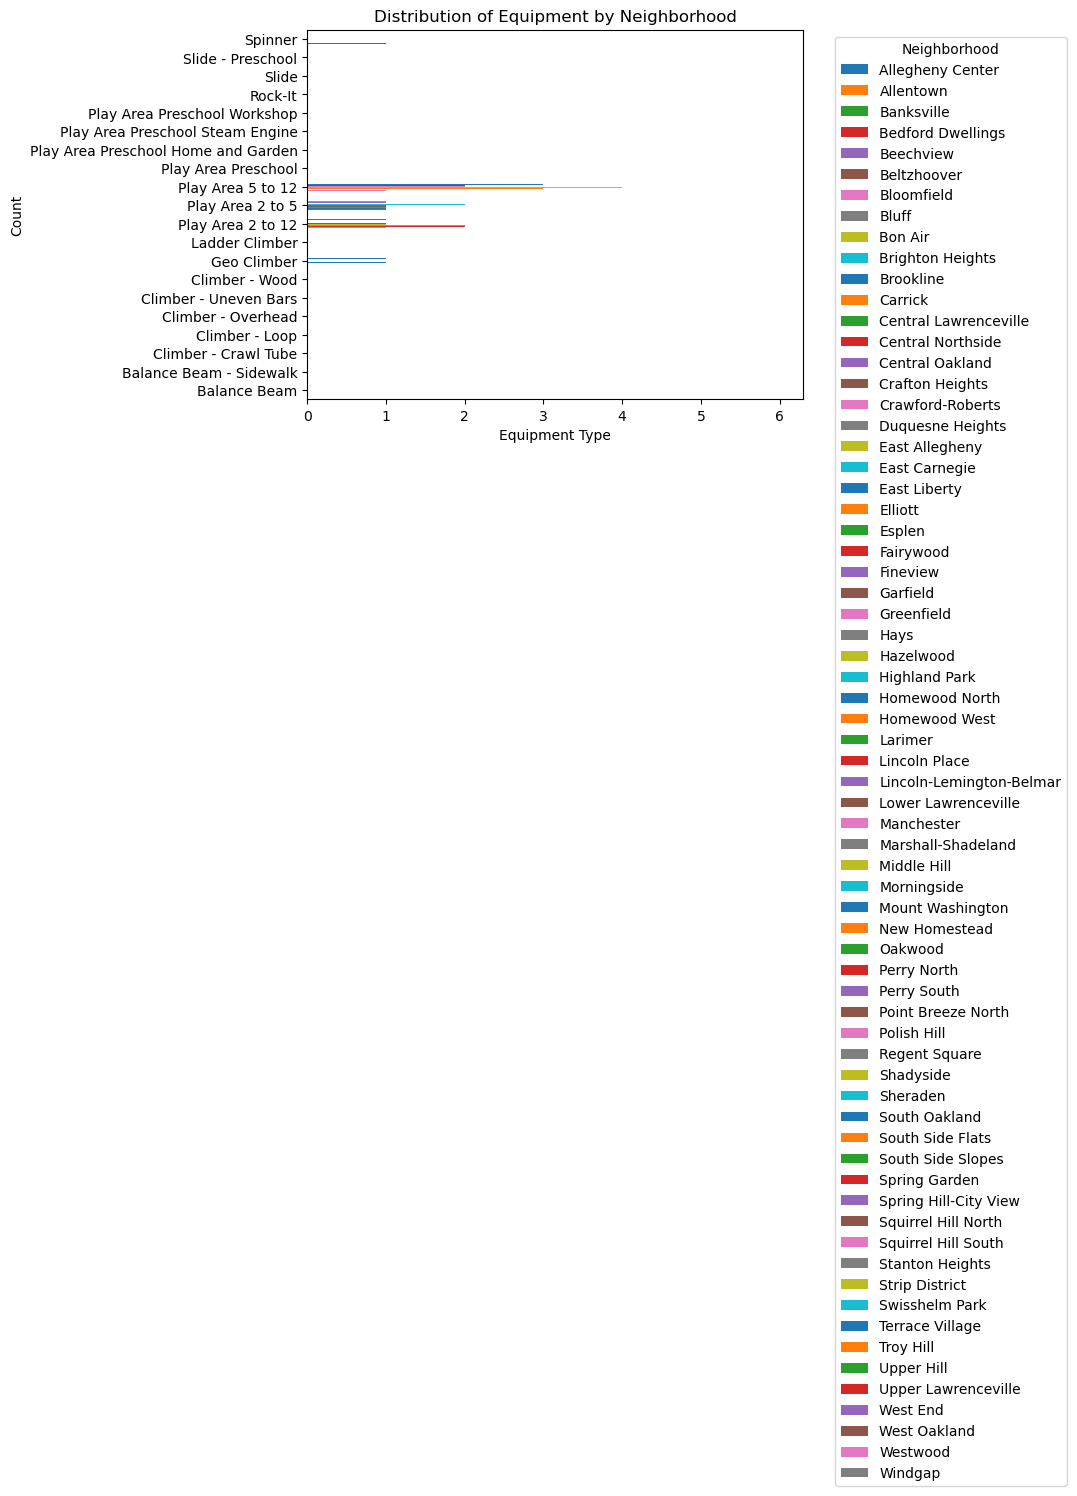

In [13]:
counts = data[["equipment_type", "neighborhood"]].value_counts().unstack().head(20)

# Plot (kind='bar' for grouped, add stacked=True for a stacked bar)
counts.plot(kind='barh')

# Formatting
plt.title("Distribution of Equipment by Neighborhood")
plt.xlabel("Equipment Type")
plt.ylabel("Count")
plt.legend(title="Neighborhood", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
data["safety_surface_type"].unique

<bound method Series.unique of 0              Pour in Place
1                SofSurfaces
2                SofSurfaces
3                SofSurfaces
4                SofSurfaces
               ...          
440              SofSurfaces
441              SofSurfaces
442    Engineered Wood Fiber
443    Engineered Wood Fiber
444    Engineered Wood Fiber
Name: safety_surface_type, Length: 445, dtype: object>

In [15]:
ada_df[["neighborhood", 'safety_surface_type']].count()

neighborhood           95
safety_surface_type    89
dtype: int64

Beechview --> most [equipment surface]
Squirrel Hill South --> most ada accessible neighborhoods

In [16]:
data.loc[(data['neighborhood'] == 'Squirrel Hill North') | (data['neighborhood'] == 'Squirrel Hill South')].groupby(['ada_accessible']).count()

,name,equipment_type,manufacturer,safety_surface_type,neighborhood
ada_accessible,,,,,
f,34,34,25,22,34
t,8,8,7,7,8


In [17]:
ada_df['neighborhood'].value_counts()

neighborhood
Squirrel Hill South         7
South Side Slopes           4
Beechview                   4
East Liberty                4
Elliott                     4
Mount Washington            3
Highland Park               3
Sheraden                    3
Hazelwood                   2
Fineview                    2
Beltzhoover                 2
Greenfield                  2
Lincoln-Lemington-Belmar    2
Brighton Heights            2
Morningside                 2
South Oakland               2
Crawford-Roberts            2
Bloomfield                  2
Carrick                     2
South Side Flats            2
Manchester                  2
New Homestead               1
Perry South                 1
Windgap                     1
Crafton Heights             1
Terrace Village             1
Bedford Dwellings           1
Polish Hill                 1
Shadyside                   1
Lincoln Place               1
Allentown                   1
Upper Hill                  1
Oakwood                    

In [18]:
# double checking that 7 ada-accessible neighborhoods in Squirrel Hill South
data.query("neighborhood == 'Squirrel Hill South' and ada_accessible == 't'")

,name,equipment_type,manufacturer,safety_surface_type,ada_accessible,neighborhood
3,Schenley Overlook Playground,Swing 2 Bays,Little Tykes,SofSurfaces,t,Squirrel Hill South
116,Schenley Bartlett Playground,Swing 3 Bays,Playworld,SofSurfaces,t,Squirrel Hill South
132,Davis Playground,Swing 3 Bays,Playworld,SofSurfaces,t,Squirrel Hill South
323,Schenley Anderson Playground,Swing 4 Bays,Big Toys,Pour in Place,t,Squirrel Hill South
332,Frick Beechwood Playground,Swing 2 Bays,Playworld,SofSurfaces,t,Squirrel Hill South
378,Schenley Oval Playground,Swing 3 Bays,Little Tykes,SofSurfaces,t,Squirrel Hill South
380,Vietnam Veteran's Playground,Swing 3 Bays,Little Tykes,SofSurfaces,t,Squirrel Hill South


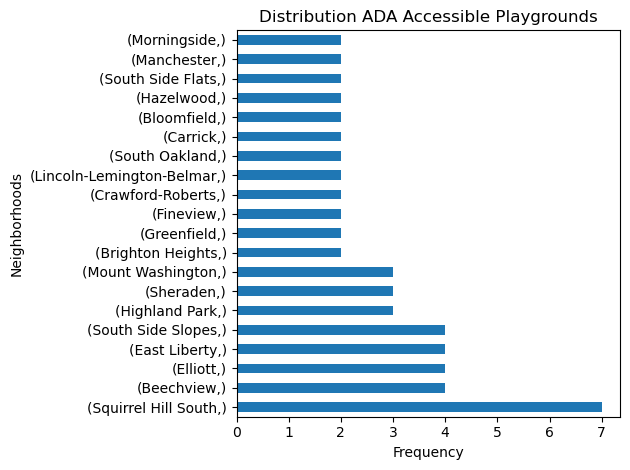

In [19]:
# plotting to see which neighborhoods have the most ada_accessible playgrounds

ada_plot = ada_df[["neighborhood"]].value_counts().head(20)

# Plot (kind='bar' for grouped, add stacked=True for a stacked bar)
ada_plot.plot(kind='barh', ax=plt.gca())

# Formatting
plt.title("Distribution ADA Accessible Playgrounds")
# plt.figure(figsize=(10, 15)) 
plt.xlabel("Frequency")
plt.ylabel("Neighborhoods")
# plt.legend(title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
ada = ada_df['neighborhood'].value_counts().head(20)
ada

neighborhood
Squirrel Hill South         7
South Side Slopes           4
Beechview                   4
East Liberty                4
Elliott                     4
Mount Washington            3
Highland Park               3
Sheraden                    3
Hazelwood                   2
Fineview                    2
Beltzhoover                 2
Greenfield                  2
Lincoln-Lemington-Belmar    2
Brighton Heights            2
Morningside                 2
South Oakland               2
Crawford-Roberts            2
Bloomfield                  2
Carrick                     2
South Side Flats            2
Name: count, dtype: int64

In [21]:
safety_surface = data[['neighborhood', 'safety_surface_type']].groupby('neighborhood').value_counts()
safety_surface

neighborhood         safety_surface_type
Allegheny Center     SofSurfaces            12
                     Tiles                   3
Allentown            Pour in Place           4
Banksville           SofSurfaces             6
Bedford Dwellings    Tiles                   3
                                            ..
Upper Lawrenceville  Pour in Place           4
West End             Pour in Place           3
West Oakland         SofSurfaces             1
Westwood             Pour in Place           2
Windgap              SofSurfaces             5
Name: count, Length: 97, dtype: int64

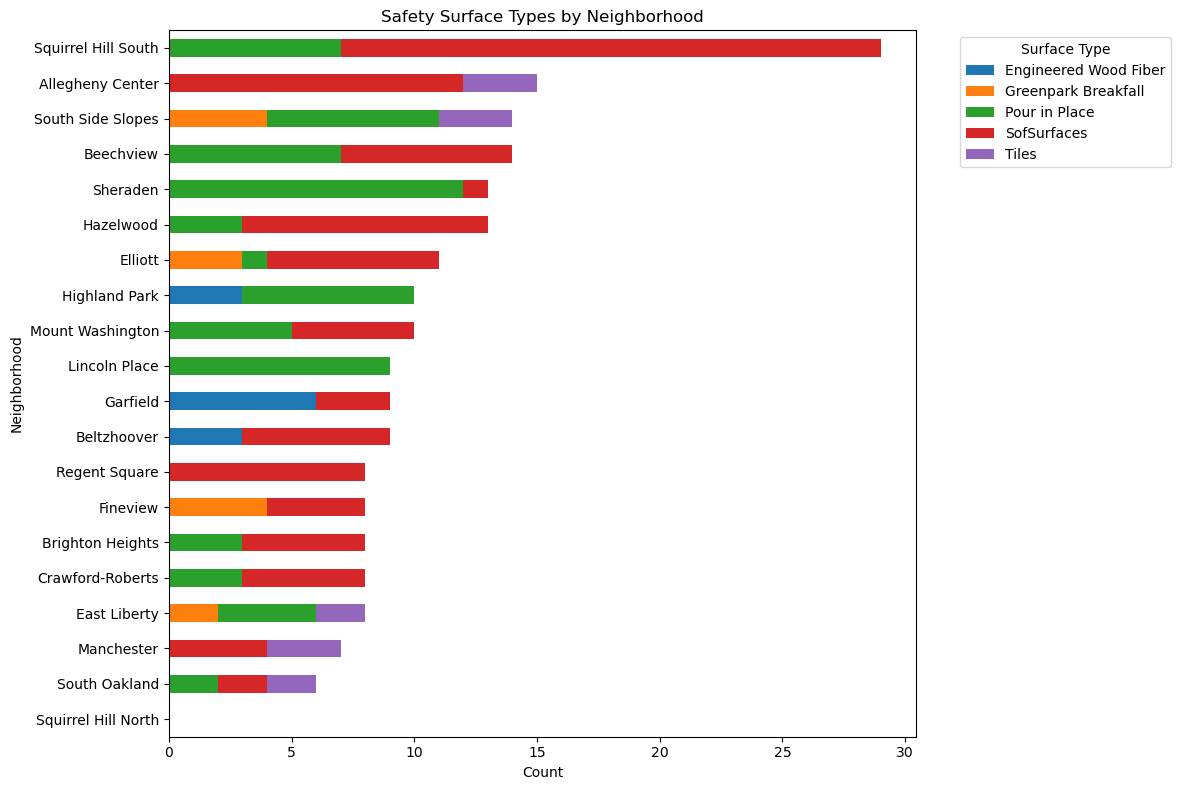

In [23]:
surface_pivot = pd.crosstab(data['neighborhood'], data['safety_surface_type'])

# Let's see the top 20 neighborhoods to keep the plot clean
top_20_neighborhoods = data['neighborhood'].value_counts().head(20).index
plot_data = surface_pivot.reindex(top_20_neighborhoods, fill_value=0)

# Plotting
plt.figure(figsize=(12, 8))
plot_data = surface_pivot.reindex(top_20_neighborhoods, fill_value=0)
plot_data = plot_data.assign(total=plot_data.sum(axis=1)).sort_values('total', ascending=True).drop(columns='total')
plot_data.plot(kind='barh', stacked=True, ax=plt.gca())

plt.title("Safety Surface Types by Neighborhood")
plt.xlabel("Count")
plt.ylabel("Neighborhood")
plt.legend(title="Surface Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In conclusion, after conducting all my exploratory data analysis, I have found that the best neighborhood in Pittburgh when it comes to playgrounds and accessibility is Squirrel Hill South. When looking looking at the distribution of ADA accessible playgrounds and which ones have the best safety surfaces for their playgrounds, Squirrel Hill South ranked number one is both categories. It also had the most playgrounds with Pour in Place/SofSurfaces as its safety surface, a firm and stable material that is very durable in the long run compared to some of its counterparts. As a group, we chose Squirrel Hill since it ranked as a top contender in my dataset, a top 2 contender in Katie's, and in the top quarter for Vais